In [2]:
%pip install qiskit qiskit-ibm-runtime
%pip install qiskit-aer
%pip install 'qiskit[visualization]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130

In [3]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
import math
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


In [22]:
pi = math.pi
q = QuantumRegister(2,'q')
c = ClassicalRegister(2,'c')
qc = QuantumCircuit(q,c)

In [5]:
QiskitRuntimeService.save_account(channel="ibm_quantum", token="Your Token Here", overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(min_num_qubits=127)

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_qc = pm.run(qc)
noise_model = NoiseModel.from_backend(backend)


IBMNotAuthorizedError: '401 Client Error: Unauthorized for url: https://auth.quantum.ibm.com/api/users/loginWithToken. Login failed., Error code: 3446.'

Grover's

In [23]:
qc.h(range(2))
qc.cz(q[0],q[1])
qc.h(range(2))
qc.x(range(2))
qc.h(q[1])
qc.cx(q[0],q[1])
qc.h(q[1])
qc.x(q[0])
qc.x(q[1])
qc.h(q[0])
qc.h(q[1])
#
qc.measure_all()

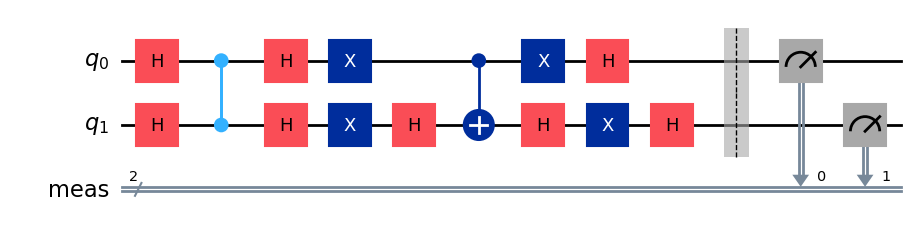

In [24]:
qc.draw('mpl', fold=False, idle_wires=False)

Run Simulation

In [12]:
simulator = AerSimulator(noise_model=noise_model)
result = simulator.run(qc).result()

NameError: name 'noise_model' is not defined

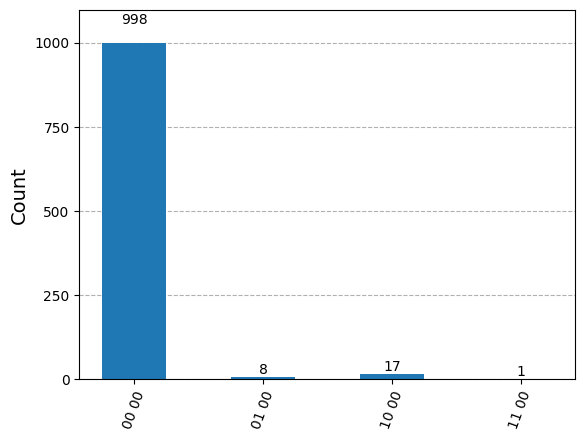

In [ ]:
counts = result.get_counts(qc)
plot_histogram(counts)

In [ ]:
simulator = AerSimulator()
result = simulator.run(qc).result()

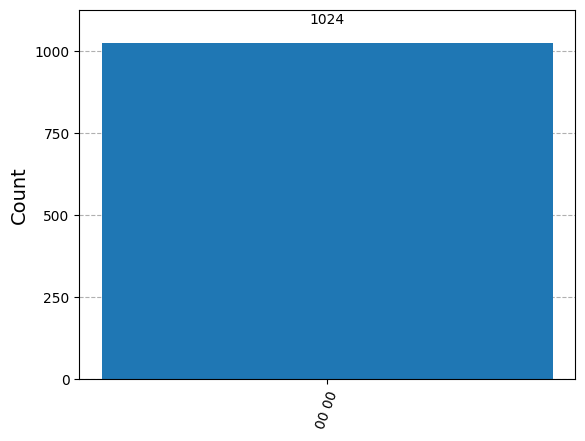

In [ ]:
counts = result.get_counts(qc)
plot_histogram(counts)

Run on IBM Quantum Computer

In [ ]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1_024
result = sampler.run([circuit_qc]).result()

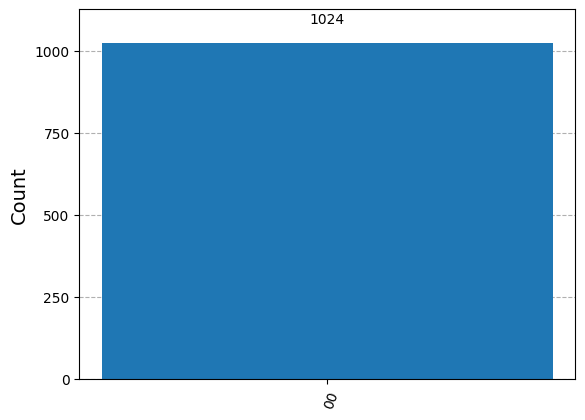

In [ ]:
dist = result[0].data.c.get_counts()
plot_histogram(dist)